In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

## Phase 1: Creating Database

In [8]:
#1.
data_dictionary_df = pd.read_csv('data/data_dictionary.csv', index_col=0)
#2.
hv_andes_global_registry_df = pd.read_csv('data/Hantavirus_Andes_Global_Registry.csv', index_col=0)
#3.
hv_clinical_df = pd.read_csv('data/hantavirus_clinical.csv', index_col=0)
#4.
hv_country_yearly_df = pd.read_csv('data/hantavirus_country_yearly.csv', index_col=0)
#5.
hv_environmental_df = pd.read_csv('data/hantavirus_environmental.csv', index_col=0)
#6.
hv_master_df = pd.read_csv('data/hantavirus_master.csv', index_col=0)
#7.
hv_monthly_trends_df = pd.read_csv('data/hantavirus_monthly_trends.csv', index_col=0)
#8.
hv_outbreaks_df = pd.read_csv('data/hantavirus_outbreaks.csv', index_col=0)
#9.
hv_virus_strains_df = pd.read_csv('data/hantavirus_virus_strains.csv', index_col=0)
#10.
sources_metadata_df = pd.read_csv('data/sources_metadata.csv', index_col=0)

In [9]:
import sqlite3

#Connect to database file in project folder
conn = sqlite3.connect('hantavirus.db')

#Save dataframes as SQL tables
data_dictionary_df.to_sql('data_dictionary', conn, if_exists='replace', index=False)
hv_andes_global_registry_df.to_sql('hv_agr', conn, if_exists='replace', index=False)
hv_clinical_df.to_sql('hv_clinical', conn, if_exists='replace', index=False)
hv_country_yearly_df.to_sql('hv_country_yearly', conn, if_exists='replace', index=False)
hv_environmental_df.to_sql('hv_environmental', conn, if_exists='replace', index=False)
hv_master_df.to_sql('hv_master', conn, if_exists='replace', index=False)
hv_monthly_trends_df.to_sql('hv_monthly_trends', conn, if_exists='replace', index=False)
hv_outbreaks_df.to_sql('hv_outbreaks', conn, if_exists='replace', index=False)
hv_virus_strains_df.to_sql('hv_virus_strains', conn, if_exists='replace', index=False)
sources_metadata_df.to_sql('sources_metadata', conn, if_exists='replace', index=False)

print('Database saved!')

Database saved!


## Phase 2: Exploratory Data Analysis & SQL Querying

In [19]:
query1 = """
    SELECT age_group, gender
    FROM hv_clinical
    WHERE severity = 'Critical'
    ORDER BY age_group
"""
critical_cases = pd.read_sql_query(query1, conn)
print(critical_cases.to_string())

     age_group  gender
0         0-14  Female
1         0-14  Female
2         0-14  Female
3         0-14  Female
4         0-14  Female
5         0-14  Female
6         0-14  Female
7         0-14  Female
8         0-14  Female
9         0-14  Female
10        0-14  Female
11        0-14  Female
12        0-14    Male
13        0-14    Male
14        0-14    Male
15        0-14    Male
16        0-14    Male
17        0-14  Female
18        0-14  Female
19        0-14  Female
20        0-14  Female
21        0-14  Female
22        0-14  Female
23        0-14    Male
24        0-14  Female
25        0-14  Female
26        0-14  Female
27        0-14  Female
28        0-14  Female
29        0-14  Female
30        0-14  Female
31        0-14  Female
32        0-14  Female
33        0-14    Male
34        0-14    Male
35        0-14    Male
36        0-14    Male
37        0-14    Male
38        0-14    Male
39        0-14    Male
40        0-14  Female
41        0-14  Female
42        0

## Phase 3: Data Visualization

In [21]:
# Global dark theme settings
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "sans-serif"
})

print("Style loaded!")

Style loaded!


### Chart 1: Distribution of Severity by Age

In [ ]:
severity_by_age = """
    SELECT age_group, gender, 
        CASE
            WHEN severity = 'Severe' THEN 2
            WHEN severity = 'Mild' THEN 0
            WHEN severity = 'Moderate' THEN 1
            WHEN severity = 'Critical' THEN 3
            ELSE NULL
        END AS severity_score
    FROM hv_clinical
    ORDER BY age_group, gender
"""

severity_dist = pd.read_sql_query(severity_by_age, conn)

     age_group  gender  severity_score
0         0-14  Female               2
1         0-14  Female               2
2         0-14  Female               1
3         0-14  Female               2
4         0-14  Female               1
...        ...     ...             ...
7533       60+    Male               0
7534       60+    Male               3
7535       60+    Male               1
7536       60+    Male               1
7537       60+    Male               1

[7538 rows x 3 columns]


Text(0.5, 1.0, 'Hantavirus Severity by Age Group and Gender')

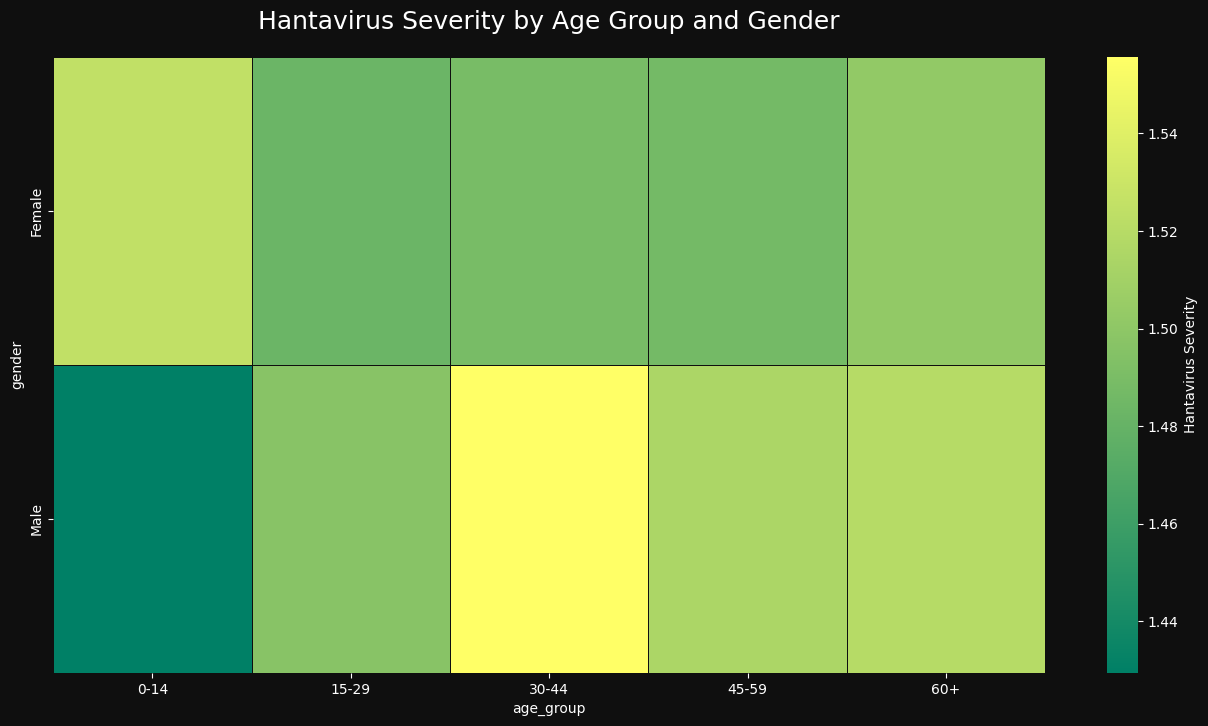

In [132]:
heatmap_pivot = severity_dist.pivot_table(
    index='gender', 
    columns='age_group',
    values='severity_score'
)

fig, ax = plt.subplots(figsize = (16,8))
sns.heatmap(
    heatmap_pivot,
    ax=ax,
    cmap = 'summer',
    linewidth = 0.5, 
    linecolor = '#0f0f0f',
    annot = False,
    cbar_kws={'label': 'Hantavirus Severity'}
)

ax.set_title('Hantavirus Severity by Age Group and Gender', fontsize = 18, pad=20)

In [81]:
dist_of_severity = """
    SELECT 
        COUNT(severity) AS severity_count, severity, virus_strain
    FROM hv_clinical
    GROUP BY severity, virus_strain
    ORDER BY virus_strain, 
        CASE severity
            WHEN 'Mild' THEN 1
            WHEN 'Moderate' THEN 2
            WHEN 'Severe' THEN 3
            WHEN 'Critical' THEN 4
        END
"""

severity_by_strain = pd.read_sql_query(dist_of_severity, conn)
#severity_by_strain

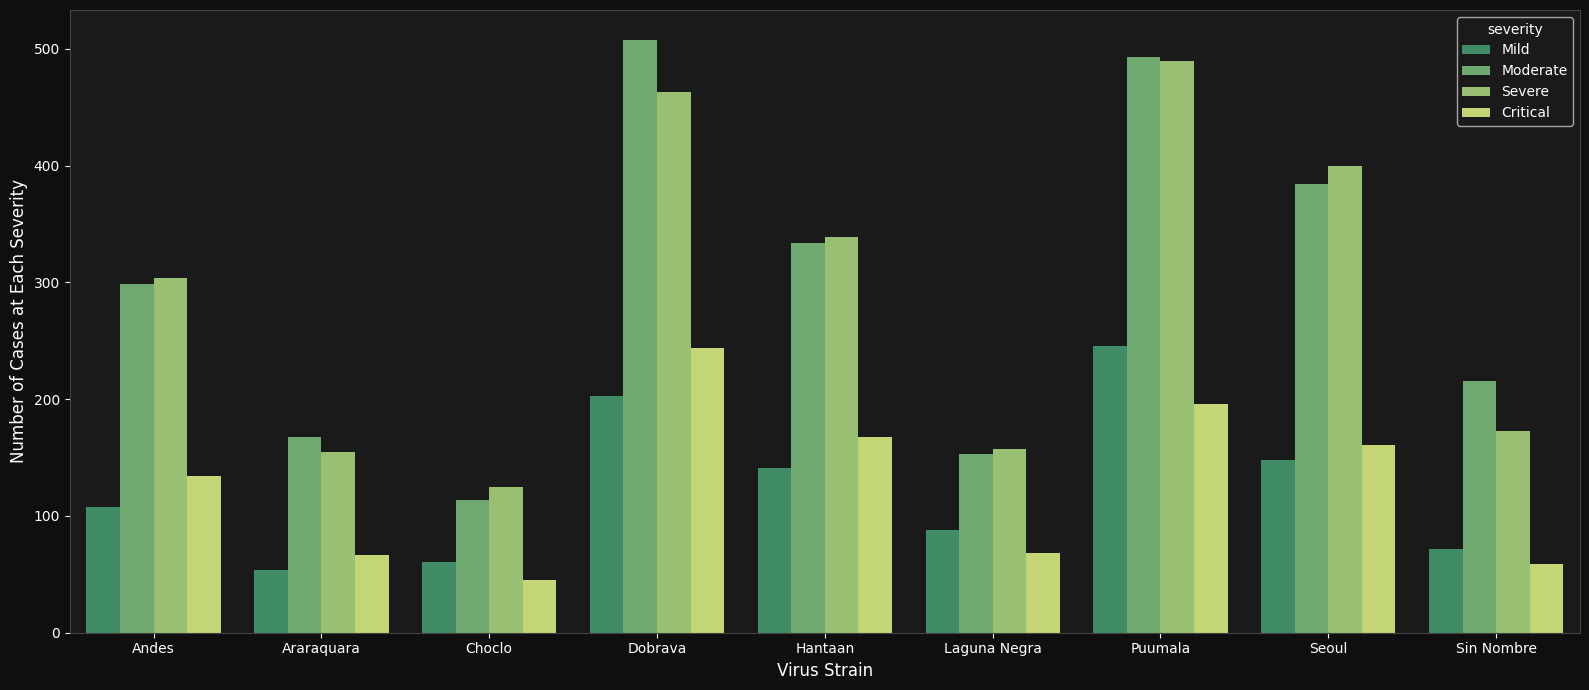

In [130]:
fig, ax = plt.subplots(figsize=(16,7))

sns.barplot(data=severity_by_strain, x='virus_strain', y='severity_count', hue='severity', palette = 'summer')
plt.xlabel('Virus Strain', fontsize=12)
plt.ylabel('Number of Cases at Each Severity', fontsize=12)

plt.tight_layout()
plt.show()

In [120]:
dist_of_deceased = """
    SELECT
        virus_strain,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS recovered,
          SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS deceased
    FROM hv_clinical
    GROUP BY virus_strain
    ORDER BY virus_strain
"""

deceased_by_strain = pd.read_sql_query(dist_of_deceased, conn)
deceased_by_strain

,virus_strain,recovered,deceased
0,Andes,587,258
1,Araraquara,304,140
2,Choclo,264,81
3,Dobrava,1298,120
4,Hantaan,920,62
5,Laguna Negra,343,123
6,Puumala,1416,9
7,Seoul,1067,26
8,Sin Nombre,380,140


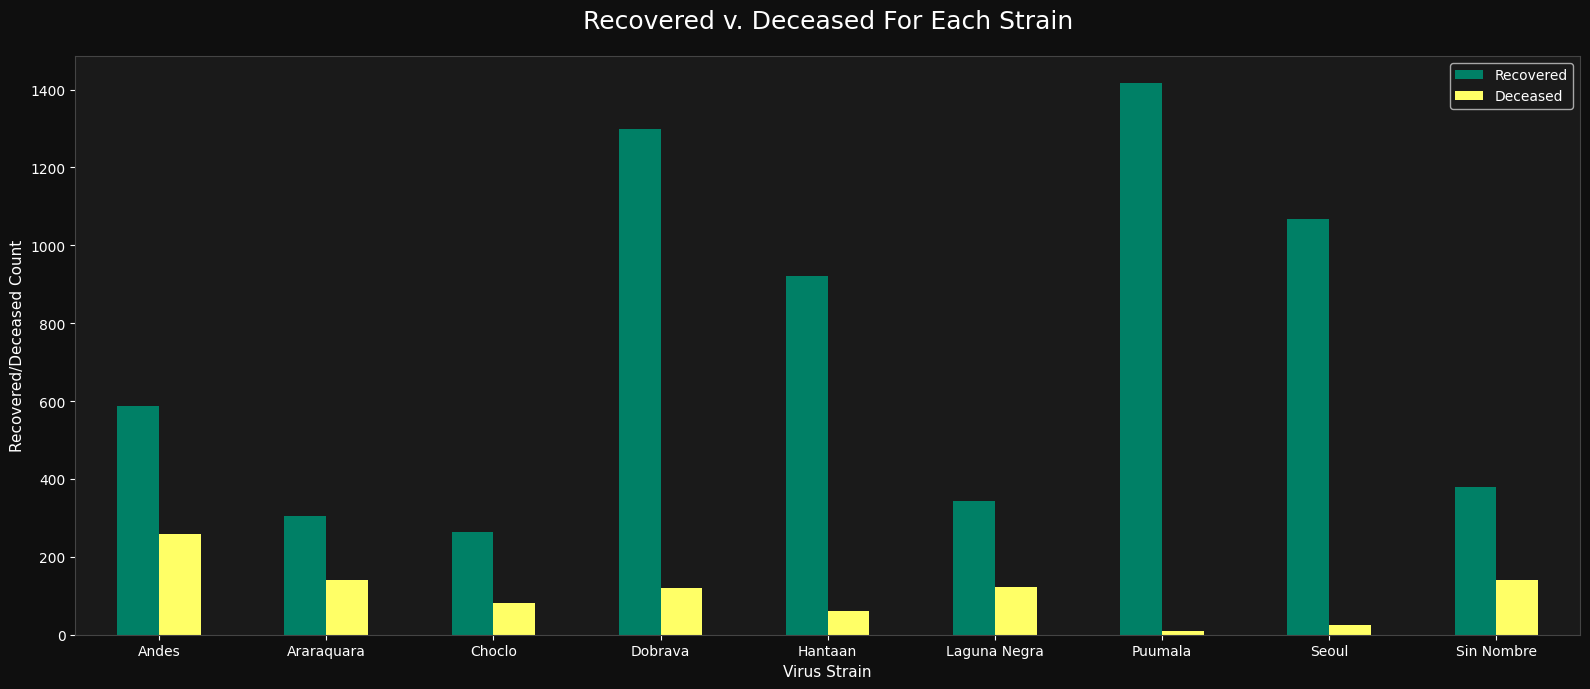

In [128]:
deceased_by_strain.plot(x='virus_strain', y=['recovered', 'deceased'], kind='bar', rot=0, figsize=(16,7), colormap='summer')

plt.title('Recovered v. Deceased For Each Strain', fontsize=18, pad=20)
plt.xlabel('Virus Strain', fontsize=11)
plt.ylabel('Recovered/Deceased Count', fontsize=11)
plt.legend(['Recovered', 'Deceased'])

plt.tight_layout()
plt.show()